You are leading a new branded hotel and you need to know what customers who give poor reviews of hotels tend to bring up. To minimize poor service, your analytics team will examine hotel reviews using topic modeling to identify what reviewers who give poor reviews actually write about in their experience to ensure your hotel focuses special attention and ensures high-quality services in those domains.

You will use the Yelp hotel reviews data to build a presentation to present to technical and non-technical co-workers and managers. The presentation should be professional and succinct (max of 10 minutes) and focus on the problem at hand including

- What topics do reviewers tend to bring up in general?
- How do happy customers differ from unhappy customers in the topics they bring up in their review?  
- Are there other characteristics about customers that would be useful to know about?
- Based on the results and what should your new hotel focus on?
- What are the main takeaways and recommendations?

You will deliver the results as a professional, team-based presentation. You should discuss the background of the problem, any important processing and modeling steps you made to arrive at your results, the key results and insights, and a set of recommendations moving forward. Your presentation should be 10 minutes and recorded. You will submit two files: (1) the recorded presentation; and (2) the code you used for your analysis.

#### Import Packages and Data
---

In [1]:
#Base Packages
import pandas as pd
import nltk
import re
import numpy as np

#Specialty Packages
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

#Visualization Packages
import plotly.graph_objects as go
import altair as alt
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


In [2]:
from google.colab import files
uploaded = files.upload()

Saving hotel_final.csv to hotel_final.csv


In [3]:
yelp = pd.read_csv("hotel_final.csv")

# Functions

In [4]:
def consolidate_concepts(text: str) -> str:
    """
    Replace concept variants with single canonical tokens before vectorization.

    Consolidations:
        WIFI: wifi, wi-fi, wi fi, internet, connection, connectivity
        AC:   a/c, ac (standalone), air conditioning/conditioner, hvac,
              temperature, thermostat, heater, heating

    Run this on the review text column before passing to CountVectorizer.
    """
    if not isinstance(text, str):
        return text

    # WIFI: order matters — match multi-word forms before single words
    text = re.sub(
        r'\b(?:wi[\s-]?fi|internet|connectivity|connection)\b',
        'WIFI',
        text,
        flags=re.IGNORECASE,
    )

    # AC: match air conditioning variants before bare "ac"
    text = re.sub(
        r'\bair[\s-]?condition(?:ing|er|ed)?\b',
        'AC',
        text,
        flags=re.IGNORECASE,
    )
    text = re.sub(
        r'\b(?:hvac|thermostat|heater|heating|temperature)\b',
        'AC',
        text,
        flags=re.IGNORECASE,
    )
    text = re.sub(
        r'\ba/c\b',
        'AC',
        text,
        flags=re.IGNORECASE,
    )
    # bare "ac" — case-sensitive lowercase only to avoid matching abbreviations
    # like "AC" in proper nouns; word boundary catches "ac" but not "academic", "acre", etc.
    text = re.sub(r'\bac\b', 'AC', text)

    return text

In [5]:
def top_words_by_relevance(
    lda_model: LatentDirichletAllocation,
    vectorizer: CountVectorizer,
    dtm,
    n_words: int = 5,
    lambda_param: float = 0.6,
    eps: float = 1e-12,
) -> list[list[str]]:
    """
    Return top-N words per topic ranked by Sievert & Shirley (2014) relevance:
        relevance(w, t) = lambda * log p(w|t) + (1 - lambda) * log [p(w|t) / p(w)]

    lambda=1.0 reduces to ranking by p(w|t) (matches sklearn's default top-words view).
    lambda=0.0 ranks purely by lift.
    lambda=0.6 is the empirically validated default for interpretability.
    """
    # p(w | t): normalize each topic row of components_ to sum to 1
    phi = lda_model.components_ / lda_model.components_.sum(axis=1, keepdims=True)

    # p(w): marginal word probability across the corpus, from the DTM
    word_counts = np.asarray(dtm.sum(axis=0)).ravel()
    p_w = word_counts / word_counts.sum()

    # Relevance score per (topic, word)
    log_phi = np.log(phi + eps)
    log_lift = np.log((phi + eps) / (p_w + eps))
    relevance = lambda_param * log_phi + (1 - lambda_param) * log_lift

    terms = vectorizer.get_feature_names_out()
    top_per_topic = [
        [terms[i] for i in row.argsort()[::-1][:n_words]]
        for row in relevance
    ]
    return top_per_topic

#### Exploratory Data Analysis
---

In [6]:
print("Data Types:")
print(yelp.dtypes)

Data Types:
Unnamed: 0        int64
reviewID         object
reviewContent    object
rating            int64
usefulCount       int64
coolCount         int64
funnyCount        int64
dtype: object


In [7]:
print(f"Number of missing ratings: {yelp["rating"].isna().sum()}")
print(f"Number of missing reviews: {yelp["reviewContent"].isna().sum()}")

Number of missing ratings: 0
Number of missing reviews: 0


In [8]:
#Histogram to show distribution of ratings
alt.Chart(yelp).mark_bar().encode(
    alt.X("rating:O"),
    y='count()',
)

alt.Chart(...)

##### Data Cleaning

In [9]:
# Remove the Yelp UI artifact
yelp['reviewContent'] = yelp['reviewContent'].str.replace(
    r'\s*Show owner comment\s*»\s*', ' ', regex=True
)

In [10]:
# good['reviewConsolidated'] = good['reviewContent'].fillna('').apply(consolidate_concepts)
# bad['reviewConsolidated'] = good['reviewContent'].fillna('').apply(consolidate_concepts)

yelp['reviewConsolidated'] = yelp['reviewContent'].fillna('').apply(consolidate_concepts)


In [11]:
#Stopwords
nltk.download('stopwords')
sw = stopwords.words("english")
sw.extend(["one",
           "would",
           "could",
           "get",
           "also",
           "got",
           "though",
           "like",
           "come",
           "room",
           "hotel"]) #Add industry specific stop words
# "hotel",
#            "room",
#            "stay",
#            "lobby",
#            "bed",
#            "night",
#            "day",
#            "time",
#            "place",

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [12]:
#Lemmatization
nltk.download('wordnet')
lem = WordNetLemmatizer()

def clean(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = [lem.lemmatize(w) for w in text.split() if w not in sw]
    return ' '.join(tokens)

yelp['reviewClean'] = yelp['reviewConsolidated'].fillna('').apply(clean)

[nltk_data] Downloading package wordnet to /root/nltk_data...


In [13]:
good = yelp[yelp["rating"] >= 4]
bad = yelp[yelp["rating"] <= 2]

##### Top Word Embeddings

In [14]:
def top_words(
    df: pd.DataFrame,
    col: str,
    head: int = 10,
    n_gram: tuple[int, int] = (1, 2),
    min_df: int = 3,
    color: str = "steelblue",
    interv: int = 1,
) -> plt.Figure:
    vectorizer = CountVectorizer(min_df=5,
                    max_df=0.9,
                    max_features=2000,
                    ngram_range=n_gram)
    vec_matrix = vectorizer.fit_transform(df[col])

    freq = vec_matrix.sum(axis=0).A1  # row vector → 1-D array
    terms = vectorizer.get_feature_names_out()

    top = (
        pd.DataFrame({"term": terms, "freq": freq})
        .nlargest(head, "freq")
        .sort_values("freq")
    )

    fig, ax = plt.subplots(figsize=(10,6))
    ax.barh(top["term"], top["freq"], color=color)
    ax.set_xlabel("Term Frequency")
    ax.xaxis.grid(True)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    # let matplotlib render ticks, then extend by 2 intervals
    fig.canvas.draw()
    ticks = ax.get_xticks()
    interval = ticks[1] - ticks[0]
    ax.set_xlim(0, ax.get_xlim()[1] + interv * interval)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(interval))
    plt.tight_layout(rect=(0,0,0.95,1))
    plt.close(fig)
    return fig


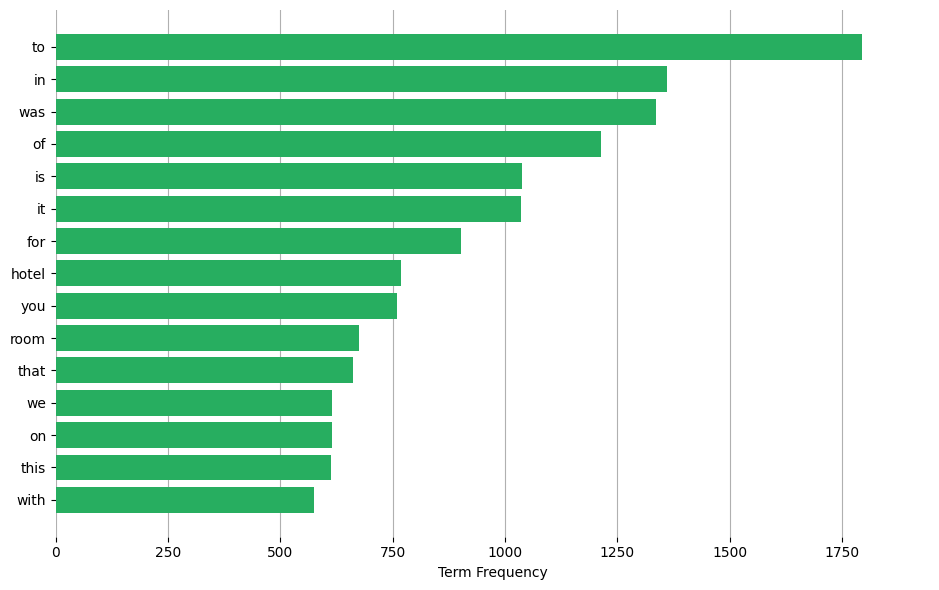

In [15]:
top_words(good, "reviewContent", head=15, n_gram=(1,2), color='#27ae60ff', interv=.25)

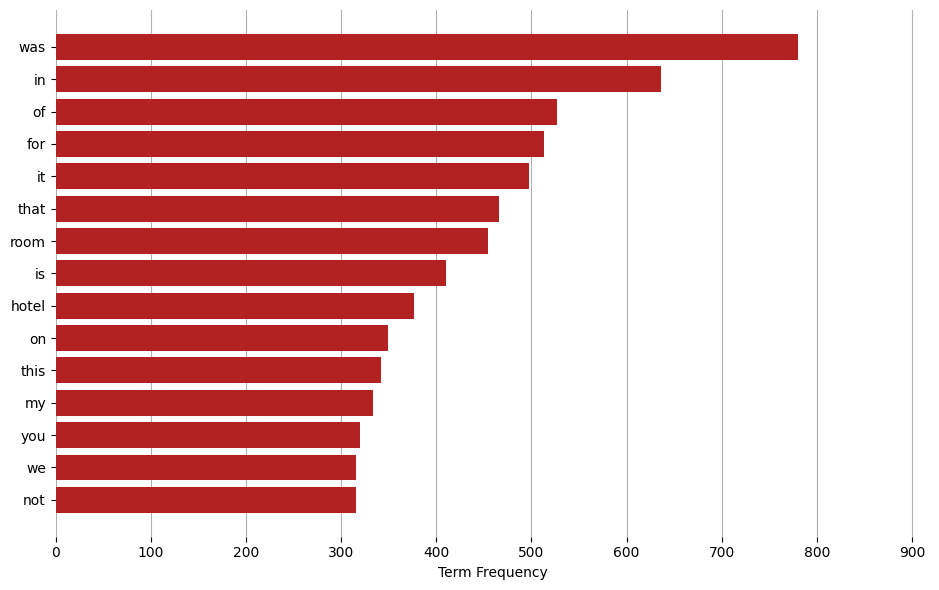

In [16]:
top_words(bad, "reviewContent", head=15, n_gram=(1,2), color='firebrick')

#### Instantiate Vectorizer, Specify Parameters
---

In [17]:
v_bad = CountVectorizer(
    min_df=5,
    max_df=0.9,
    max_features=2000,
    ngram_range=(1,2)
) #   removed stop_words=sw,

# X_bad = v_bad.fit_transform(bad["reviewContent"])
X_bad = v_bad.fit_transform(bad['reviewClean'])


# LDA model
lda_bad = LatentDirichletAllocation(
    n_components=8,
    learning_method='online',
    max_iter=20,
    random_state=315,
    doc_topic_prior=None,
    n_jobs=-1
)

topics_bad = lda_bad.fit_transform(X_bad)

print(f"There are {lda_bad.components_.shape[0]} topics and {lda_bad.components_.shape[1]} words")
voc = np.array(v_bad.get_feature_names_out())
n_words = 5
imp_words = lambda x: [voc[each] for each in np.argsort(x)[:-n_words-1:-1]]
words_in_topic = ([imp_words(x) for x in lda_bad.components_])
words_in_topic


There are 8 topics and 806 words


[['place', 'review', 'left', 'came', 'suite'],
 ['bed', 'desk', 'front', 'night', 'front desk'],
 ['service', 'stay', 'place', 'room', 'night'],
 ['room', 'guest', 'place', 'received', 'special'],
 ['mini', 'cost', 'mini bar', 'stayed', 'night'],
 ['management', 'return', 'literally', 'gave', 'near'],
 ['parking', 'bathroom', 'way', 'shower', 'ac'],
 ['room', 'water', 'bottle water', 'house', 'street']]

In [18]:
v_good = CountVectorizer(
    min_df=5,
    max_df=0.9,
    max_features=2000,
    ngram_range=(1,2)
) #    stop_words=sw,

# X_good = v_good.fit_transform(good["reviewContent"])
X_good = v_good.fit_transform(good['reviewClean'])

# LDA model
lda_good = LatentDirichletAllocation(
    n_components=8,
    learning_method='online',
    max_iter=20,
    random_state=315,
    doc_topic_prior=None,
    n_jobs=-1
)

topics_good = lda_good.fit_transform(X_good)

print(f"There are {lda_good.components_.shape[0]} topics and {lda_good.components_.shape[1]} words")

voc_good = np.array(v_good.get_feature_names_out())
n_words = 5
imp_words = lambda x: [voc_good[each] for each in np.argsort(x)[:-n_words-1:-1]]
words_in_topic_good = ([imp_words(x) for x in lda_good.components_])

words_in_topic_good


There are 8 topics and 1519 words


[['event', 'lake shore', 'accommodation', 'shore', 'enjoy'],
 ['spa', 'bliss', 'lakeshore', 'great', 'bliss spa'],
 ['great', 'view', 'nice', 'location', 'night'],
 ['chicago', 'view', 'great', 'stay', 'room'],
 ['night', 'palmer', 'house', 'palmer house', 'time'],
 ['five star', 'five', 'chic', 'star', 'wifi'],
 ['great', 'lobby', 'staff', 'room', 'nice'],
 ['inn', 'cool', 'pretty', 'wave', 'pretty cool']]

In [19]:
# Negative model
neg_top = top_words_by_relevance(lda_bad, v_bad, X_bad, n_words=5, lambda_param=0.6)

# Positive model
pos_top = top_words_by_relevance(lda_good, v_good, X_good, n_words=5, lambda_param=0.6)

In [20]:
neg_top

[['shame', 'suite', 'review', 'left', 'must'],
 ['bed', 'desk', 'front', 'front desk', 'night'],
 ['service', 'place', 'stay', 'room', 'wifi'],
 ['guest', 'special', 'received', 'reserved', 'group'],
 ['mini bar', 'mini', 'cannot', 'airport', 'cost'],
 ['management', 'return', 'literally', 'near', 'gave'],
 ['parking', 'shower', 'ac', 'bathroom', 'cool'],
 ['bottle water', 'bottle', 'water', 'room small', 'river']]

In [21]:
pos_top

[['accommodation', 'lake shore', 'event', 'view navy', 'responsive'],
 ['spa', 'bliss', 'lakeshore', 'bliss spa', 'lakeshore drive'],
 ['great', 'view', 'boyfriend', 'nice view', 'great experience'],
 ['chicago', 'view', 'city', 'hotel', 'location'],
 ['palmer', 'house', 'palmer house', 'night', 'time'],
 ['five star', 'five', 'chic', 'offering', 'free wifi'],
 ['staff', 'great', 'bed', 'lobby', 'business'],
 ['inn', 'pretty cool', 'lake shore', 'wave', 'food drink']]

In [22]:
"""
Slide 5 & 6 — Topic prevalence charts
Run after cells 24–26 (both models fitted, topics_bad and topics_good available)
"""
# ── Theme labels (must match slide 4 order: topic index → label) ─────────

POS_LABELS = {
    0: "Events & Venues",
    1: "Spa & Lakeshore",
    2: "Views & Experience",
    3: "Location & Chicago",
    4: "Palmer House",
    5: "Luxury & Amenities",
    6: "Staff & Lobby",
    7: "Dining & Ambience",
}

NEG_LABELS = {
    0: "Suite Disappointments",
    1: "Front Desk & Room",
    2: "Service & WIFI",
    3: "Reservations & Groups",
    4: "Minibar & Cost",
    5: "Management Issues",
    6: "Parking, AC & Bathroom",
    7: "Room Size & Water",
}

# ── Highlighted topics (the 3 called out on each slide's left side) ──────

POS_HIGHLIGHTED = {3, 0, 2}   # Location & Chicago, Events & Venues, Views & Experience
NEG_HIGHLIGHTED = {1, 2, 6}   # Front Desk & Room, Service & WIFI, Parking AC & Bathroom


# ── Compute prevalence ───────────────────────────────────────────────────

def compute_prevalence(doc_topic_matrix):
    """Hard-assign each doc to its dominant topic, return counts and pcts."""
    assigned = doc_topic_matrix.argmax(axis=1)
    n = len(assigned)
    k = doc_topic_matrix.shape[1]
    counts = np.array([(assigned == t).sum() for t in range(k)])
    pcts = counts / n * 100
    return counts, pcts


# ── Plot function ────────────────────────────────────────────────────────

def plot_prevalence(
    pcts,
    labels: dict,
    highlighted: set,
    accent_color: str,
    muted_color: str,
    title: str,
    filename: str | None = None,
):
    """
    Horizontal bar chart of topic prevalence.

    Parameters
    ----------
    pcts : array-like, length k
        Percent of reviews assigned to each topic.
    labels : dict
        {topic_index: "Theme Label"} for all k topics.
    highlighted : set
        Topic indices to draw in accent_color (the 3 on the slide's left side).
    accent_color, muted_color : str
        Bar colors.
    title : str
        Chart title text.
    filename : str or None
        If provided, saves to this path at 300 DPI.
    """
    k = len(pcts)
    order = np.argsort(pcts)  # ascending → bottom-to-top in barh

    sorted_pcts = pcts[order]
    sorted_labels = [labels[i] for i in order]
    sorted_colors = [accent_color if i in highlighted else muted_color for i in order]

    fig, ax = plt.subplots(figsize=(6.5, 4.5))

    bars = ax.barh(range(k), sorted_pcts, color=sorted_colors, height=0.65)

    # Value labels at bar ends
    for bar, pct in zip(bars, sorted_pcts):
        ax.text(
            bar.get_width() + 0.8,
            bar.get_y() + bar.get_height() / 2,
            f"{pct:.0f}%",
            va="center",
            ha="left",
            fontsize=10,
            fontfamily="DejaVu Sans",
            color="#2C3E50",
        )

    ax.set_yticks(range(k))
    ax.set_yticklabels(sorted_labels, fontsize=11, fontfamily="DejaVu Sans", color="#1E2761")
    ax.set_xlabel("")
    ax.set_title(title, fontsize=12, fontfamily="DejaVu Sans", fontweight="bold",
                 color="#1E2761", loc="left", pad=12)

    # X-axis as percentage
    ax.xaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))
    ax.set_xlim(0, max(sorted_pcts) * 1.2)

    # Clean up spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.tick_params(left=False, bottom=False)
    ax.xaxis.set_visible(False)

    plt.tight_layout()

    if filename:
        fig.savefig(filename, dpi=300, bbox_inches="tight", facecolor="white")
        print(f"Saved: {filename}")

    plt.close(fig)
    return fig


Saved: slide5_prevalence.png


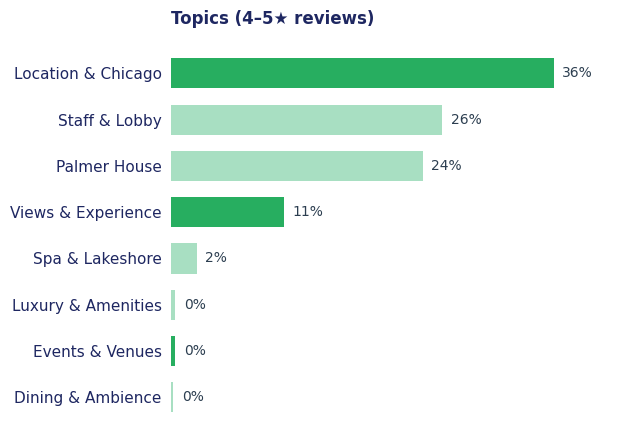

In [23]:
# ── Generate both charts ─────────────────────────────────────────────────

# Positive (slide 5)
pos_counts, pos_pcts = compute_prevalence(topics_good)
plot_prevalence(
    pos_pcts,
    labels=POS_LABELS,
    highlighted=POS_HIGHLIGHTED,
    accent_color="#27ae60",
    muted_color="#a8dfc2",
    title="Topics (4–5★ reviews)",
    filename="slide5_prevalence.png",
)


Saved: slide6_prevalence.png


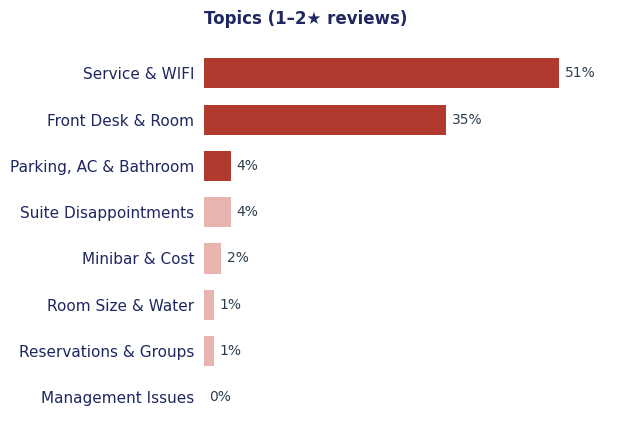

In [24]:
# Negative (slide 6)
neg_counts, neg_pcts = compute_prevalence(topics_bad)
plot_prevalence(
    neg_pcts,
    labels=NEG_LABELS,
    highlighted=NEG_HIGHLIGHTED,
    accent_color="#B03A2E",
    muted_color="#E8B4B0",
    title="Topics (1–2★ reviews)",
    filename="slide6_prevalence.png",
)

/tmp/ipykernel_8167/1604909921.py:44: RuntimeWarning: Mean of empty slice.
  rows.append((NEG_LABELS[t], neg_ratings[mask].mean() - overall_mean, mask.sum()))
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Saved: slide7_deviation.png | Overall mean: 3.481


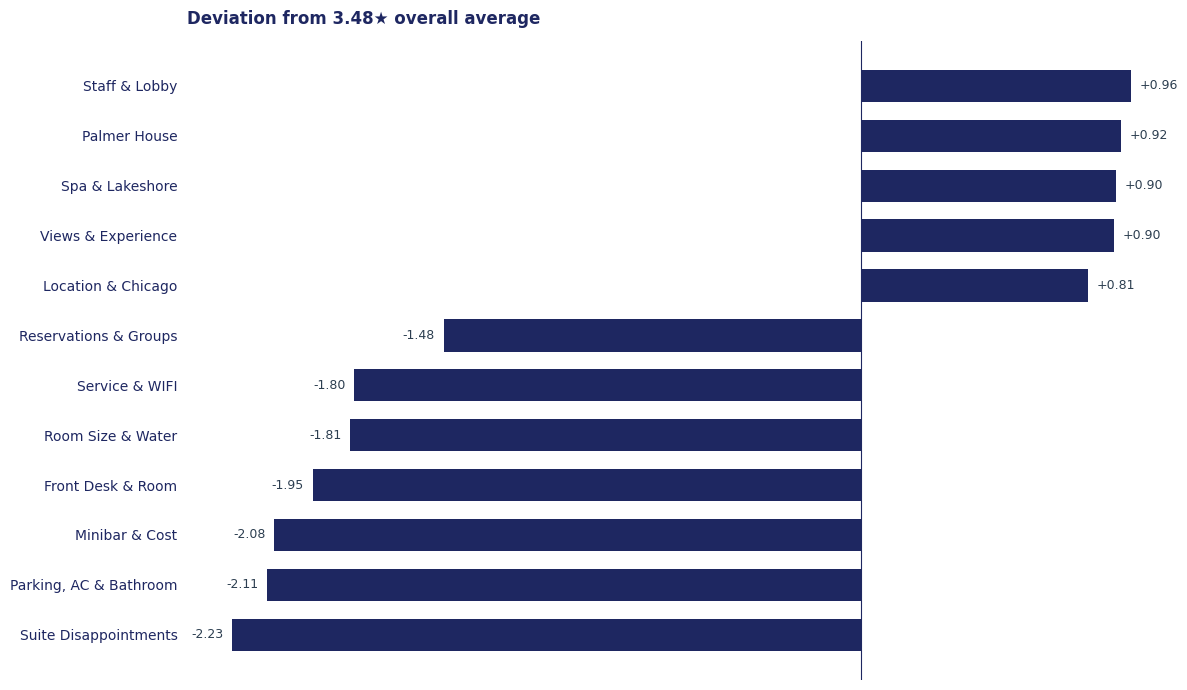

In [25]:
# ── Slide 7: Divergent bar — deviation from mean rating ──────────────────

import numpy as np
import matplotlib.pyplot as plt

POS_LABELS = {
    0: "Events & Venues",
    1: "Spa & Lakeshore",
    2: "Views & Experience",
    3: "Location & Chicago",
    4: "Palmer House",
    5: "Luxury & Amenities",
    6: "Staff & Lobby",
    7: "Dining & Ambience",
}

NEG_LABELS = {
    0: "Suite Disappointments",
    1: "Front Desk & Room",
    2: "Service & WIFI",
    3: "Reservations & Groups",
    4: "Minibar & Cost",
    5: "Management Issues",
    6: "Parking, AC & Bathroom",
    7: "Room Size & Water",
}

overall_mean = yelp['rating'].mean()

# Hard assignment
pos_assigned = topics_good.argmax(axis=1)
neg_assigned = topics_bad.argmax(axis=1)

pos_ratings = good['rating'].values
neg_ratings = bad['rating'].values

# Build (label, deviation, n) tuples for all 16 topics
rows = []
for t in range(8):
    mask = pos_assigned == t
    rows.append((POS_LABELS[t], pos_ratings[mask].mean() - overall_mean, mask.sum()))
for t in range(8):
    mask = neg_assigned == t
    rows.append((NEG_LABELS[t], neg_ratings[mask].mean() - overall_mean, mask.sum()))

# Sort by deviation: most positive at top
rows.sort(key=lambda r: r[1])  # ascending for barh (bottom-to-top)

# Filter out topics with too few docs for a meaningful mean
MIN_DOCS = 3
rows = [r for r in rows if r[2] >= MIN_DOCS]

labels = [r[0] for r in rows]
devs = np.array([r[1] for r in rows])
counts = [r[2] for r in rows]

# Colors: green for positive deviation, red for negative
# New
colors = "#1E2761"

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(range(len(devs)), devs, color=colors, height=0.65)

# Zero line
ax.axvline(0, color="#1E2761", linewidth=0.8)

# Value labels
for i, (bar, dev, n) in enumerate(zip(bars, devs, counts)):
    offset = 0.03 if dev >= 0 else -0.03
    ha = "left" if dev >= 0 else "right"
    ax.text(
        dev + offset,
        bar.get_y() + bar.get_height() / 2,
        f"{dev:+.2f}",
        va="center",
        ha=ha,
        fontsize=9,
        fontfamily="DejaVu Sans",
        color="#2C3E50",
    )

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=10, fontfamily="DejaVu Sans", color="#1E2761")
ax.set_title(
    f"Deviation from {overall_mean:.2f}★ overall average",
    fontsize=12, fontfamily="DejaVu Sans", fontweight="bold",
    color="#1E2761", loc="left", pad=12,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.tick_params(left=False, bottom=False)
ax.xaxis.set_visible(False)

plt.tight_layout()
fig.savefig("slide7_deviation.png", dpi=300, bbox_inches="tight", facecolor="white")
print(f"Saved: slide7_deviation.png | Overall mean: {overall_mean:.3f}")

from IPython.display import display
display(fig)
plt.close(fig)

In [26]:
neg_assigned = topics_bad.argmax(axis=1)
bad_with_topic = bad.copy()
bad_with_topic['topic'] = neg_assigned

for topic_id in [1, 2, 6]:
    label = NEG_LABELS[topic_id]
    docs = bad_with_topic[bad_with_topic['topic'] == topic_id]
    print(f"\n{'='*80}\nTopic {topic_id}: {label}  ({len(docs)} reviews)\n{'='*80}")
    for _, row in docs.iterrows():
        print(f"\n[{row['rating']}★ | id={row['reviewID']}]")
        print(row['reviewContent'])
        print("-" * 80)


Topic 1: Front Desk & Room  (71 reviews)

[2★ | id=wxfgopuQejwJVxIr0ISh5g]
The service at the w is the worst. Checking in no porter or bell man. Checked in at the front desk and told the lady. She said would you like help with your bags. I said absolutely and told her no one was out front to help. Waited. No one shows up. I take them myself. Concierge is totally unhelpful and completely overwhelmed. The front desk, they live here but don't know where anything is. I just travel advisor it or google map it. Unreal. The wave restaurant is opposite. Food is delicious and service is excellent!!! Checking out, waited 25 minutes for luggage assistance and guess what no one shows up and again I take it downstairs myself. I tell the front desk again. They say they'll send someone up and again I bring the luggage down myself. Worst service in this hotel.
--------------------------------------------------------------------------------

[1★ | id=gjtrzPQ2ooGf48JoOYm6tg]
The hotel is decent: nice d